<a href="https://colab.research.google.com/github/LaisST/FIAP_Datathon_Fase_5/blob/main/Codigo/Datathon_Analise_Exploratoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Datathon - Fase 5
# Case Passos Mágicos

## Objetivo

Este projeto tem como objetivo analisar o desenvolvimento educacional de crianças e jovens atendidos pela Associação Passos Mágicos, utilizando dados dos anos de 2022 a 2024, com o intuito de identificar padrões de desempenho, engajamento e aspectos psicossociais que impactam a trajetória dos alunos.

Além disso, o projeto propõe o desenvolvimento de um modelo preditivo capaz de identificar, de forma antecipada, alunos em risco de defasagem escolar, possibilitando intervenções mais rápidas e eficazes.



## Analise Exploratória

### Importação das Bibliotecas

In [1]:
# Tratativa das bases
import numpy as np
import pandas as pd

#Visualização dos gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Preparação e treino do modelo
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

#Validação do modelo
from sklearn.metrics import accuracy_score

### Importação da Base

In [2]:
# Importar o arquivo do github
url = "https://raw.githubusercontent.com/LaisST/FIAP_Datathon_Fase_5/refs/heads/main/Bases/base_tratada.csv"

df_tratado = pd.read_csv(url)

In [3]:
# Exibir primeiras linhas
df_tratado.head()

,RA,Fase,Turma,Nome,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra,...,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,IPP,Ano_Referencia,Destaque IPV.1,Ativo/ Inativo.1,Ativo/ Inativo,Escola
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Quartzo,...,-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,2022,NaN,NaN,NaN,NaN
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,2022,NaN,NaN,NaN,NaN
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ágata,...,0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,NaN,2022,NaN,NaN,NaN,NaN
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Quartzo,...,0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,2022,NaN,NaN,NaN,NaN
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,2022,NaN,NaN,NaN,NaN


### Entendimento inicial dos dados

In [4]:
# Analisar o tamanho da base
print(f"Linhas: {df_tratado.shape[0]}")
print(f"Colunas: {df_tratado.shape[1]}")

Linhas: 3030
Colunas: 38


In [5]:
# Analisar tipos de dados
df_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     3030 non-null   object 
 1   Fase                   3030 non-null   object 
 2   Turma                  3030 non-null   object 
 3   Nome                   3030 non-null   object 
 4   Data de Nasc           3030 non-null   object 
 5   Idade                  3030 non-null   object 
 6   Gênero                 3030 non-null   object 
 7   Ano ingresso           3030 non-null   int64  
 8   Instituição de ensino  3029 non-null   object 
 9   Pedra                  2883 non-null   object 
 10  INDE                   2883 non-null   object 
 11  Cg                     860 non-null    float64
 12  Cf                     860 non-null    float64
 13  Ct                     860 non-null    float64
 14  Nº Av                  2954 non-null   float64
 15  IAA 

### Qualidade dos dados (Limpeza)

In [6]:
# Identificar colunas com valores nulos
df_tratado.isnull().sum()

,0
RA,0
Fase,0
Turma,0
Nome,0
Data de Nasc,0
Idade,0
Gênero,0
Ano ingresso,0
Instituição de ensino,1
Pedra,147


In [7]:
# Identificar colunas com valores duplicados
df_tratado.duplicated().sum()

np.int64(0)

#### Tipos incorretos

Corrigir os tipos de dados incorretos

In [8]:
# Alterar os tipos de dados das colunas que são numericas, mas estão como string

df_tratado['INDE'] = pd.to_numeric(df_tratado['INDE'], errors='coerce')
df_tratado['Idade'] = pd.to_numeric(df_tratado['Idade'], errors='coerce')
df_tratado['Data de Nasc'] = pd.to_datetime(df_tratado['Data de Nasc'], errors='coerce')

In [9]:
df_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   RA                     3030 non-null   object        
 1   Fase                   3030 non-null   object        
 2   Turma                  3030 non-null   object        
 3   Nome                   3030 non-null   object        
 4   Data de Nasc           860 non-null    datetime64[ns]
 5   Idade                  2631 non-null   float64       
 6   Gênero                 3030 non-null   object        
 7   Ano ingresso           3030 non-null   int64         
 8   Instituição de ensino  3029 non-null   object        
 9   Pedra                  2883 non-null   object        
 10  INDE                   2845 non-null   float64       
 11  Cg                     860 non-null    float64       
 12  Cf                     860 non-null    float64       
 13  Ct 

#### Exclusão das colunas desnecessárias

In [10]:
# Excluir colunas nulas que não serão usadas no modelo
colunas_remover = [
    'Destaque IPV.1',
    'Cg', 'Cf', 'Ct',
    'Destaque IEG',
    'Destaque IDA',
    'Destaque IPV',
    'Ativo/ Inativo',
    'Ativo/ Inativo.1',
    'Escola'
]

df_tratado = df_tratado.drop(columns=colunas_remover, errors='ignore')

Foram removidas colunas com alto percentual de valores ausentes ou com baixa relevância para a análise, visando reduzir ruído e melhorar a qualidade dos dados utilizados nas etapas posteriores.

#### Analisar o padrão de valores de cada coluna

In [11]:
# Consutar os valores unicos por coluna para avaliar se há algum valor (resposta) fora do padrão (Apenas resposta Strings)
valores_colunas = df_tratado.select_dtypes(include='object').columns

for col in valores_colunas:
    print(f"\n{col}:")
    print(df_tratado[col].unique())


RA:
['RA-1' 'RA-2' 'RA-3' ... 'RA-1659' 'RA-1660' 'RA-1661']

Fase:
['7' '6' '5' '4' '3' '2' '1' '0' 'ALFA' 'FASE 1' 'FASE 2' 'FASE 3'
 'FASE 4' 'FASE 5' 'FASE 6' 'FASE 7' 'FASE 8' '1A' '1B' '1C' '1D' '1E'
 '1G' '1H' '1J' '1K' '1L' '1M' '1N' '1P' '1R' '2A' '2B' '2C' '2D' '2G'
 '2H' '2I' '2K' '2L' '2M' '2N' '2P' '2R' '2U' '3A' '3B' '3C' '3D' '3F'
 '3G' '3H' '3I' '3K' '3L' '3M' '3N' '3P' '3R' '3U' '4A' '4B' '4C' '4F'
 '4H' '4L' '4M' '4N' '4R' '5A' '5B' '5C' '5D' '5F' '5G' '5L' '5M' '5N'
 '6A' '6L' '7A' '7E' '8A' '8B' '8D' '8E' '8F' '9']

Turma:
['A' 'D' 'B' 'C' 'F' 'K' 'L' 'H' 'P' 'E' 'G' 'I' 'M' 'N' 'J' 'Q' 'U' 'R'
 'O' 'S' 'T' 'V' 'Y' 'Z' 'ALFA A - G0/G1' 'ALFA B - G2/G3'
 'ALFA C - G0/G1' 'ALFA D - G2/G3' 'ALFA E - G2/G3' 'ALFA F - G0/G1'
 'ALFA G - G2/G3' 'ALFA H - G0/G1' 'ALFA I - G2/G3' 'ALFA J - G2/G3'
 'ALFA K - G0/G1' 'ALFA L - G2/G3' 'ALFA M - G0/G1' 'ALFA N - G2/G3'
 'ALFA O - G2/G3' 'ALFA Q - G2/G3' 'ALFA R - G0/G1' 'ALFA S - G2/G3'
 'ALFA T - G2/G3' 'ALFA U - G2/G3' 'ALFA V

#### Padronizar os valores das colunas

In [12]:
# Padronizar os valores da coluna Genero
df_tratado['Gênero'] = df_tratado['Gênero'].replace({
    'Menina': 'Feminino',
    'Menino': 'Masculino'
})

In [13]:
# Padronizar os valores da coluna Pedra
df_tratado['Pedra'] = df_tratado['Pedra'].replace({
    'Agata': 'Ágata',
    'INCLUIR': None
})

In [14]:
# Padronizar os valores da coluna Instituição de ensino criando uma coluna de categoria
def padronizar_instituicao(x):
    if pd.isna(x):
        return 'Não informado'
    x = x.lower()

    if 'pública' in x:
        return 'Pública'
    elif 'privada' in x or 'parceria' in x:
        return 'Privada'
    elif 'universitário' in x:
        return 'Universitário'
    elif 'concluiu' in x:
        return 'Concluído'
    else:
        return 'Outros'

df_tratado['Instituicao_cat'] = df_tratado['Instituição de ensino'].apply(padronizar_instituicao)

In [15]:
# Padronizar a coluna Fase, pegando apenas os números da fase
import re

def extrair_fase(x):
    if pd.isna(x):
        return None

    x = str(x)

    # pega número da fase
    match = re.search(r'\d+', x)
    if match:
        return int(match.group())

    if 'ALFA' in x.upper():
        return 0

    return None

df_tratado['Fase_num'] = df_tratado['Fase'].apply(extrair_fase)

In [16]:
# Preencher os NA da coluna piscicologia
df_tratado['Rec Psicologia'] = df_tratado['Rec Psicologia'].fillna('Não informado')

In [17]:
# Transformar valores das colunas abaixo em binario para facilitar o modelo
df_tratado['Indicado_flag'] = df_tratado['Indicado'].map({
    'Sim': 1,
    'Não': 0
})

df_tratado['Atingiu_PV_flag'] = df_tratado['Atingiu PV'].map({
    'Sim': 1,
    'Não': 0
})

In [18]:
# Conferir alterações
valores_colunas_padronizados = df_tratado.select_dtypes(include='object').columns

for col in valores_colunas_padronizados:
    print(f"\n{col}:")
    print(df_tratado[col].unique())


RA:
['RA-1' 'RA-2' 'RA-3' ... 'RA-1659' 'RA-1660' 'RA-1661']

Fase:
['7' '6' '5' '4' '3' '2' '1' '0' 'ALFA' 'FASE 1' 'FASE 2' 'FASE 3'
 'FASE 4' 'FASE 5' 'FASE 6' 'FASE 7' 'FASE 8' '1A' '1B' '1C' '1D' '1E'
 '1G' '1H' '1J' '1K' '1L' '1M' '1N' '1P' '1R' '2A' '2B' '2C' '2D' '2G'
 '2H' '2I' '2K' '2L' '2M' '2N' '2P' '2R' '2U' '3A' '3B' '3C' '3D' '3F'
 '3G' '3H' '3I' '3K' '3L' '3M' '3N' '3P' '3R' '3U' '4A' '4B' '4C' '4F'
 '4H' '4L' '4M' '4N' '4R' '5A' '5B' '5C' '5D' '5F' '5G' '5L' '5M' '5N'
 '6A' '6L' '7A' '7E' '8A' '8B' '8D' '8E' '8F' '9']

Turma:
['A' 'D' 'B' 'C' 'F' 'K' 'L' 'H' 'P' 'E' 'G' 'I' 'M' 'N' 'J' 'Q' 'U' 'R'
 'O' 'S' 'T' 'V' 'Y' 'Z' 'ALFA A - G0/G1' 'ALFA B - G2/G3'
 'ALFA C - G0/G1' 'ALFA D - G2/G3' 'ALFA E - G2/G3' 'ALFA F - G0/G1'
 'ALFA G - G2/G3' 'ALFA H - G0/G1' 'ALFA I - G2/G3' 'ALFA J - G2/G3'
 'ALFA K - G0/G1' 'ALFA L - G2/G3' 'ALFA M - G0/G1' 'ALFA N - G2/G3'
 'ALFA O - G2/G3' 'ALFA Q - G2/G3' 'ALFA R - G0/G1' 'ALFA S - G2/G3'
 'ALFA T - G2/G3' 'ALFA U - G2/G3' 'ALFA V

In [19]:
df_tratado.head()

,RA,Fase,Turma,Nome,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra,...,IPV,IAN,Fase Ideal,Defasagem,IPP,Ano_Referencia,Instituicao_cat,Fase_num,Indicado_flag,Atingiu_PV_flag
0,RA-1,7,A,Aluno-1,2003-01-01,19.0,Feminino,2016,Escola Pública,Quartzo,...,7.278,5.0,Fase 8 (Universitários),-1,NaN,2022,Pública,7,1.0,0.0
1,RA-2,7,A,Aluno-2,2005-01-01,17.0,Feminino,2017,Rede Decisão,Ametista,...,6.778,10.0,Fase 7 (3º EM),0,NaN,2022,Outros,7,0.0,0.0
2,RA-3,7,A,Aluno-3,2005-01-01,17.0,Feminino,2016,Rede Decisão,Ágata,...,7.556,10.0,Fase 7 (3º EM),0,NaN,2022,Outros,7,0.0,0.0
3,RA-4,7,A,Aluno-4,2005-01-01,17.0,Masculino,2017,Rede Decisão,Quartzo,...,5.278,10.0,Fase 7 (3º EM),0,NaN,2022,Outros,7,0.0,0.0
4,RA-5,7,A,Aluno-5,2005-01-01,17.0,Feminino,2016,Rede Decisão,Ametista,...,7.389,10.0,Fase 7 (3º EM),0,NaN,2022,Outros,7,0.0,0.0


Foi realizada a padronização das variáveis categóricas, corrigindo inconsistências de grafia, diferenças de capitalização e redundâncias. Além disso, foram criadas variáveis derivadas, como representações numéricas de fases e variáveis binárias, visando melhorar a qualidade da análise e a performance dos modelos preditivos.

#### Outliers

In [20]:
# Consultar se há outliers extremos nas colunas númericos
df_tratado[[    'INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'IPP',
    'Mat', 'Por', 'Ing',
    'Nº Av',
    'Idade',
    'Defasagem']].describe()

,INDE,IAA,IEG,IPS,IDA,IPV,IAN,IPP,Mat,Por,Ing,Nº Av,Idade,Defasagem
count,2845.000000,2865.000000,2954.000000,2859.000000,2852.000000,2852.000000,3030.000000,1992.000000,2846.000000,2845.000000,1091.000000,2954.000000,2631.000000,3030.000000
mean,7.269915,7.918225,7.945696,6.287129,6.375964,7.545476,7.179043,7.555203,6.161595,6.430668,6.289413,3.031821,12.548081,-0.642904
std,0.991767,2.626209,2.152281,1.792491,1.956637,1.084347,2.535266,0.938990,2.398341,2.138916,2.732636,1.063670,3.283307,0.866382
min,3.032000,0.000000,0.000000,2.500000,0.000000,2.500000,2.500000,2.500000,0.000000,0.000000,0.000000,0.000000,7.000000,-5.000000
25%,6.675200,7.900000,7.300000,5.020000,5.100000,6.984000,5.000000,7.083333,4.800000,5.200000,4.500000,2.000000,10.000000,-1.000000
50%,7.388267,8.751000,8.600000,7.500000,6.666667,7.583000,5.000000,7.500000,6.300000,6.700000,6.700000,3.000000,12.000000,-1.000000
75%,7.986867,9.500000,9.400000,7.510000,7.833333,8.255000,10.000000,8.125000,8.000000,8.000000,8.500000,4.000000,15.000000,0.000000
max,9.531325,10.002000,10.000000,10.000000,10.000000,10.010000,10.000000,10.000000,10.000000,10.000000,10.000000,6.000000,27.000000,3.000000


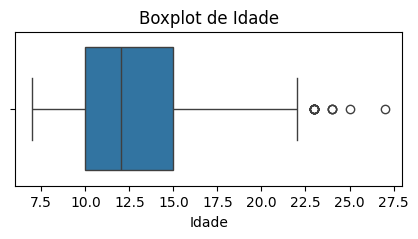

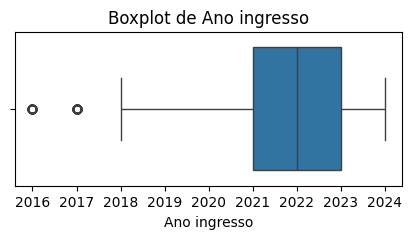

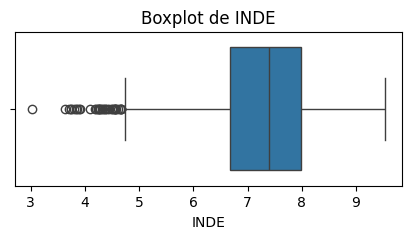

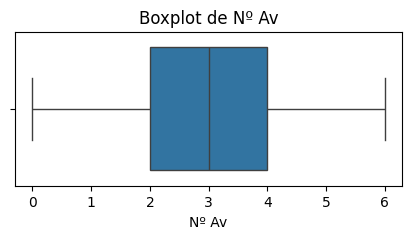

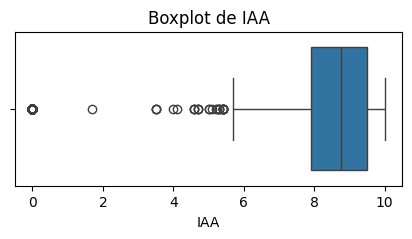

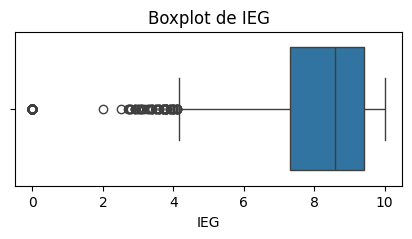

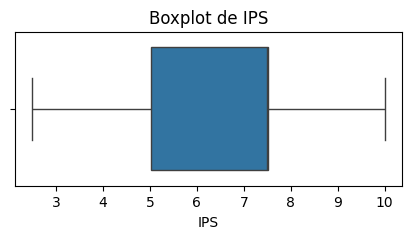

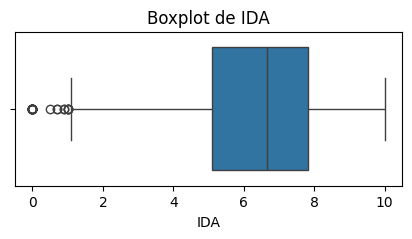

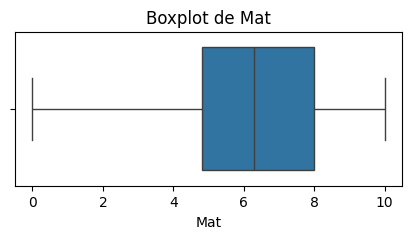

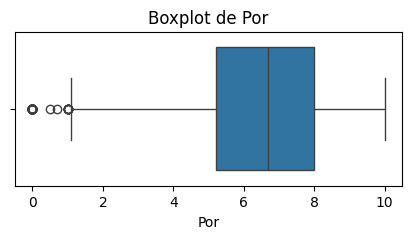

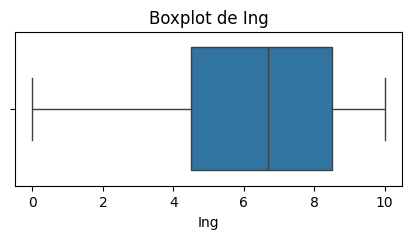

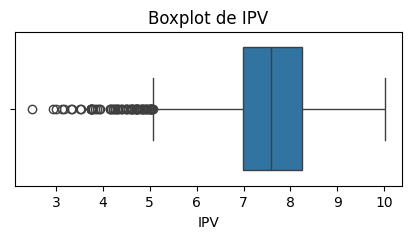

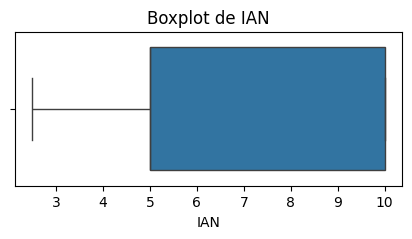

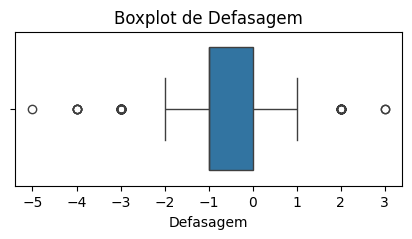

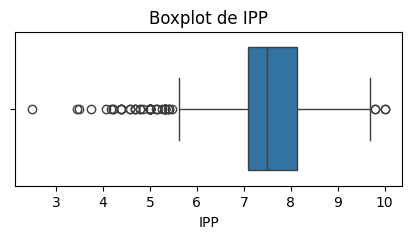

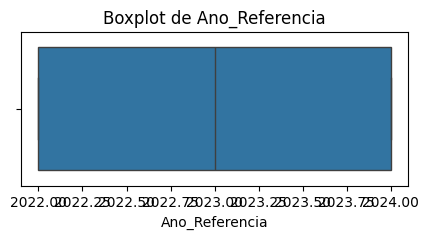

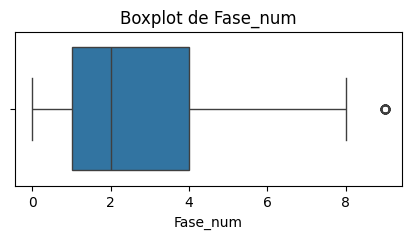

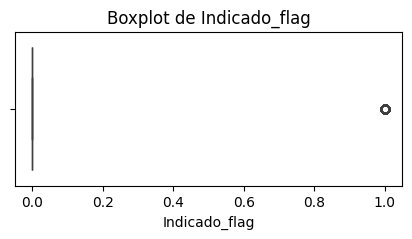

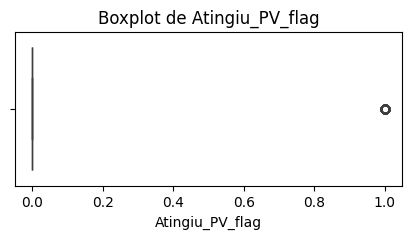

In [21]:
# Analise com Boxplot para confirmar a ausencia de outliers
num_cols = df_tratado.select_dtypes(include='number').columns
num_cols


for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df_tratado[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

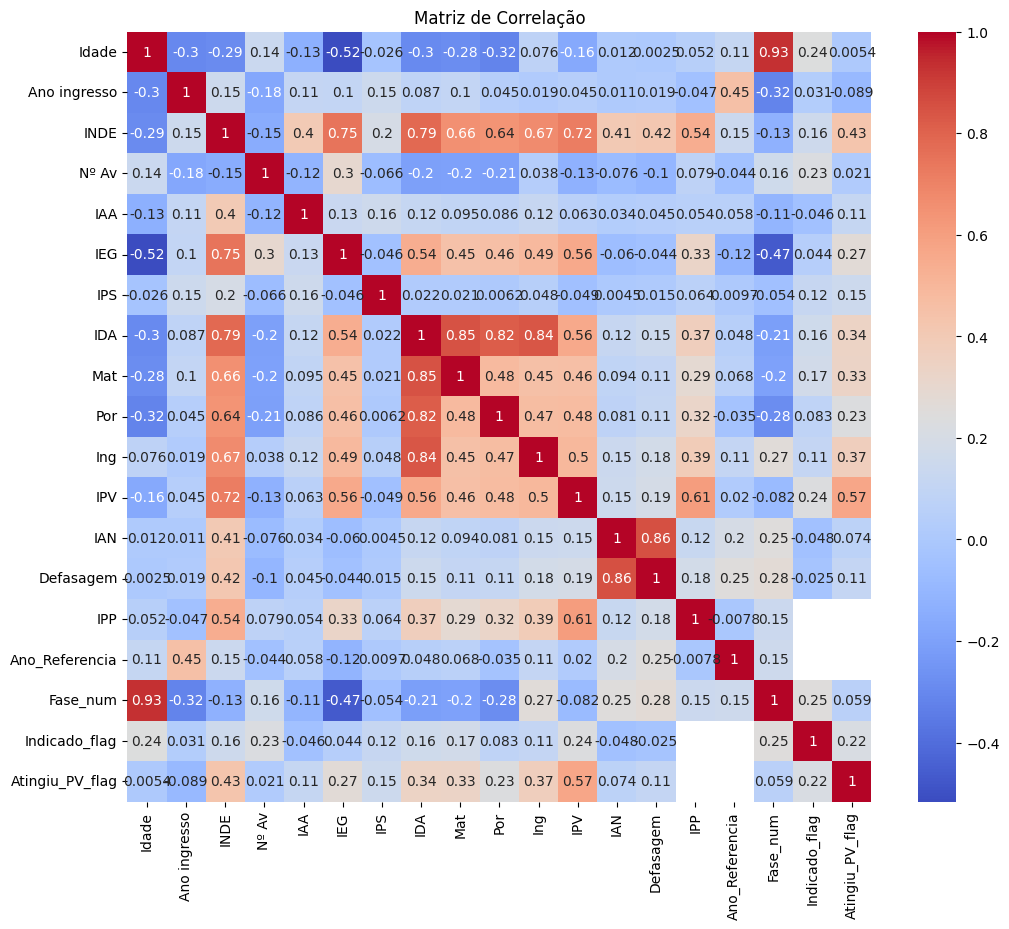

In [22]:

# selecionar apenas colunas numéricas
df_num = df_tratado.select_dtypes(include=['float64', 'int64'])

# matriz de correlação
corr = df_num.corr()

# plot
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

## Analise Direcionada

Perguntas para ser respondidas na análise

### 1. Adequação do nível (IAN)
Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao
longo do ano?

In [23]:
# Classificar o resultado do IAN em categorias
def classificar_risco(x):
    if pd.isna(x):
        return 'Não informado'
    elif x >= 8:
        return 'Sem risco'
    elif x >= 6:
        return 'Baixo risco'
    elif x >= 4:
        return 'Risco moderado'
    else:
        return 'Alto risco'

df_tratado['nivel_risco'] = df_tratado['IAN'].apply(classificar_risco)

In [26]:
# Análisar a distribuição
df_tratado['nivel_risco'].value_counts(normalize=True)

,proportion
nivel_risco,
Risco moderado,0.541914
Sem risco,0.443234
Alto risco,0.014851


A análise do indicador de adequação de nível (IAN) revela que a maioria dos alunos se encontra em situação de risco moderado de defasagem (54,19%), enquanto uma parcela significativa já apresenta desempenho adequado (44,32%). Apenas 1,48% dos alunos estão em alto risco, indicando que casos mais críticos são menos frequentes dentro da base analisada

In [37]:
# Quantidade de alunos por nível e ano
df_count_nivel = df_tratado.groupby(['Ano_Referencia', 'nivel_risco']).size().reset_index(name='quantidade')
df_count_nivel

,Ano_Referencia,nivel_risco,quantidade
0,2022,Alto risco,28
1,2022,Risco moderado,573
2,2022,Sem risco,259
3,2023,Alto risco,14
4,2023,Risco moderado,538
5,2023,Sem risco,462
6,2024,Alto risco,3
7,2024,Risco moderado,531
8,2024,Sem risco,622


In [39]:
# Quantidade de alunos por ano
df_total_Nivel = df_tratado.groupby('Ano_Referencia').size().reset_index(name='total')
df_total_Nivel

,Ano_Referencia,total
0,2022,860
1,2023,1014
2,2024,1156


In [50]:
# Calcular a evolução por ano
df_evolucao_nivel = df_count_nivel.merge(df_total_Nivel, on='Ano_Referencia')
df_evolucao_nivel['proporcao'] = (df_evolucao_nivel['quantidade'] / df_evolucao_nivel['total'])*100
df_evolucao_nivel

,Ano_Referencia,nivel_risco,quantidade,total,proporcao
0,2022,Alto risco,28,860,3.255814
1,2022,Risco moderado,573,860,66.627907
2,2022,Sem risco,259,860,30.116279
3,2023,Alto risco,14,1014,1.380671
4,2023,Risco moderado,538,1014,53.057199
5,2023,Sem risco,462,1014,45.562130
6,2024,Alto risco,3,1156,0.259516
7,2024,Risco moderado,531,1156,45.934256
8,2024,Sem risco,622,1156,53.806228


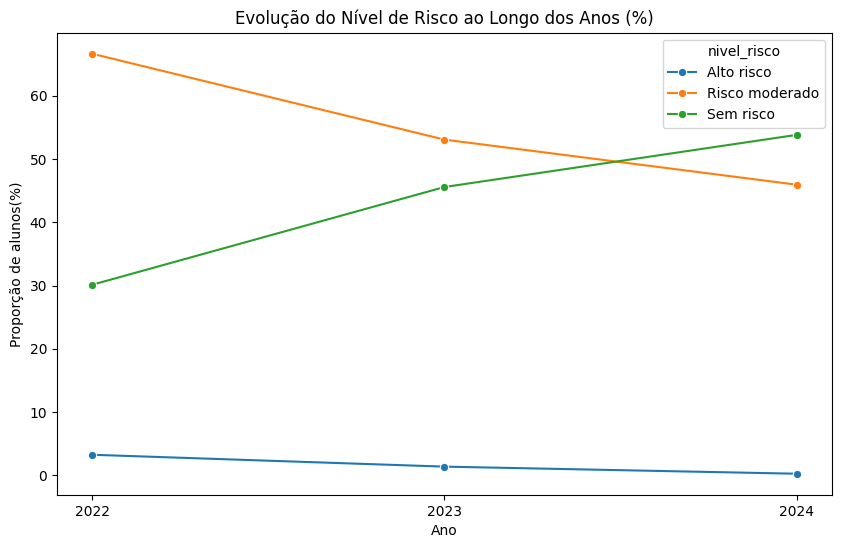

In [52]:
# Gráfico com a evolução do nível anualmente
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_evolucao_nivel,
    x=df_evolucao_nivel['Ano_Referencia'].astype(str),
    y='proporcao',
    hue='nivel_risco',
    marker='o'
)

plt.title('Evolução do Nível de Risco ao Longo dos Anos (%)')
plt.ylabel('Proporção de alunos(%)')
plt.xlabel('Ano')

plt.show()

Podemos observar uma melhora consistente no nível de adequação dos alunos ao longo dos anos, evidenciada pela redução dos casos classificados como alto risco e risco moderado, além do aumento expressivo na proporção de alunos sem risco. Esse movimento indica um impacto positivo e progressivo do programa educacional, contribuindo de forma efetiva para a redução da defasagem ao longo do tempo.

### 2. Desempenho acadêmico (IDA)
desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

In [57]:
# Evolução do Desempenho acadêmico (IDA) médio por ano
df_ida_ano = df_tratado.groupby('Ano_Referencia')['IDA'].mean().reset_index()
df_ida_ano

,Ano_Referencia,IDA
0,2022,6.092907
1,2023,6.663394
2,2024,6.351422


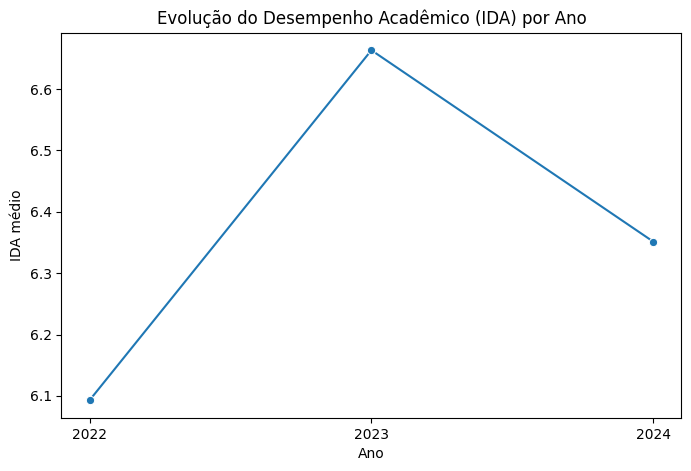

In [58]:
# Gráfico com a evolução anual
plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_ida_ano,
    x='Ano_Referencia',
    y='IDA',
    marker='o'
)

plt.title('Evolução do Desempenho Acadêmico (IDA) por Ano')
plt.ylabel('IDA médio')
plt.xlabel('Ano')

plt.xticks(df_ida_ano['Ano_Referencia'])

plt.show()

O desempenho acadêmico médio apresenta melhora entre 2022 e 2023, seguida de uma leve redução em 2024. Apesar da oscilação, os valores se mantêm relativamente próximos, indicando estabilidade.

In [59]:
# Desempenho por fase
df_ida_fase = df_tratado.groupby('Fase_num')['IDA'].mean().reset_index()
df_ida_fase

,Fase_num,IDA
0,0,7.302836
1,1,6.684091
2,2,6.187106
3,3,5.392974
4,4,5.966608
5,5,6.140148
6,6,6.920395
7,7,5.932108
8,8,8.000000
9,9,NaN


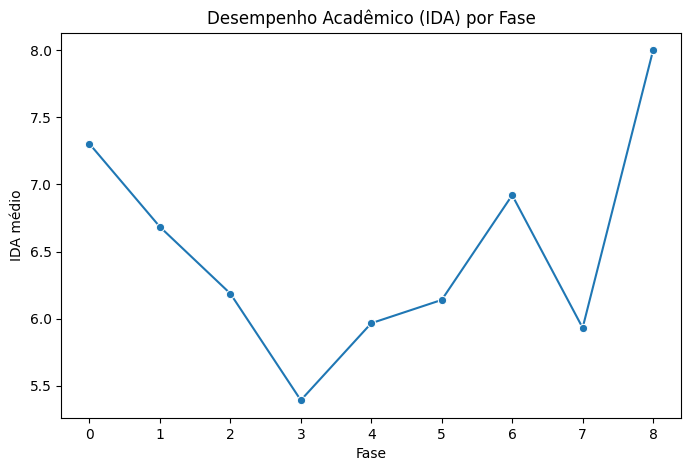

In [60]:
# Gráfico da evolução do desempenho por fase
plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_ida_fase,
    x='Fase_num',
    y='IDA',
    marker='o'
)

plt.title('Desempenho Acadêmico (IDA) por Fase')
plt.ylabel('IDA médio')
plt.xlabel('Fase')

plt.show()

Os dados sugerem que existem fases específicas com maior dificuldade, especialmente nas transições iniciais e intermediárias, indicando a necessidade de intervenções pedagógicas direcionadas nesses momentos para evitar queda no desempenho. O aumento significativo do desempenho na fase final pode estar associado a um efeito de retenção, onde apenas alunos com melhor desempenho permanecem no programa.


### 3. Engajamento nas atividades (IEG)
O grau de engajamento dos alunos (IEG) tem relação direta com seus
indicadores de desempenho (IDA) e do ponto de virada (IPV)?

#### Engajamento x Desempenho

In [62]:
# Criar a correlação entre os indicadores
df_tratado[['IEG', 'IDA', 'IPV']].corr()

,IEG,IDA,IPV
IEG,1.000000,0.539057,0.558200
IDA,0.539057,1.000000,0.557072
IPV,0.558200,0.557072,1.000000


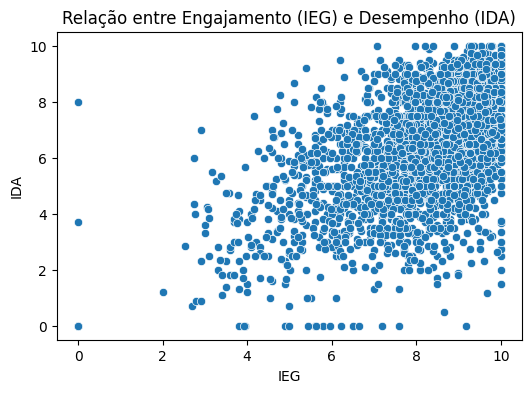

In [69]:
# Gráfico de correlação entre Engajamento e Desempenho
plt.figure(figsize=(6,4))

sns.scatterplot(data=df_tratado, x='IEG', y='IDA')

plt.title('Relação entre Engajamento (IEG) e Desempenho (IDA)')
plt.show()

<Axes: xlabel='faixa_IEG', ylabel='IDA'>

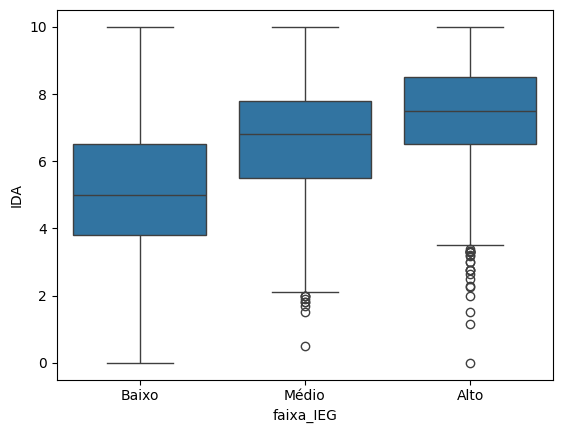

In [68]:
df_tratado['faixa_IEG'] = pd.qcut(df_tratado['IEG'], 3, labels=['Baixo', 'Médio', 'Alto'])

sns.boxplot(data=df_tratado, x='faixa_IEG', y='IDA')

Observa-se uma relação positiva entre o engajamento (IEG) e o desempenho acadêmico (IDA), indicando que alunos mais engajados tendem a apresentar melhores resultados. No entanto, a dispersão dos dados sugere que o engajamento, embora relevante, não é o único fator que influencia o desempenho.

#### Engajamento x Ponto de Virada

In [71]:
# Agrupar por nível
df_tratado['faixa_IEG'] = pd.qcut(df_tratado['IEG'], 3, labels=['Baixo', 'Médio', 'Alto'])
df_tratado.groupby('faixa_IEG')['IPV'].mean()

/tmp/ipykernel_23980/403762324.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tratado.groupby('faixa_IEG')['IPV'].mean()


,IPV
faixa_IEG,
Baixo,6.809352
Médio,7.605879
Alto,8.145030


<Axes: xlabel='faixa_IEG', ylabel='IPV'>

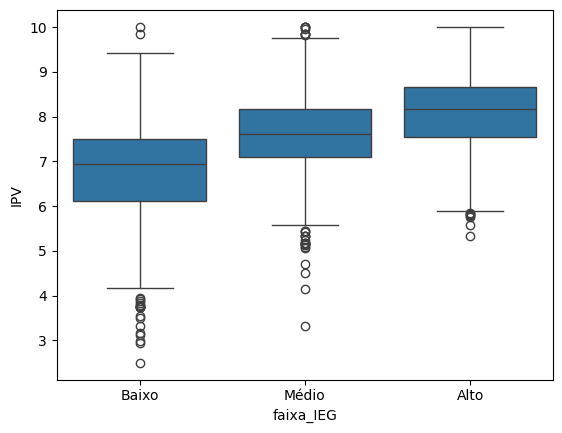

In [72]:
# Grafico de Engajamento x Ponto de virada
sns.boxplot(data=df_tratado, x='faixa_IEG', y='IPV')

O boxplot evidencia uma relação crescente entre engajamento e ponto de virada, com aumento progressivo da mediana conforme o nível de engajamento se eleva. Além disso, alunos com menor engajamento apresentam maior dispersão e maior ocorrência de valores baixos, indicando maior instabilidade nos resultados.

### 4. Autoavaliação (IAA)
As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu
desempenho real (IDA) e engajamento (IEG)?

In [73]:
# Correlação
df_tratado[['IAA', 'IDA', 'IEG']].corr()

,IAA,IDA,IEG
IAA,1.000000,0.115241,0.133078
IDA,0.115241,1.000000,0.539057
IEG,0.133078,0.539057,1.000000


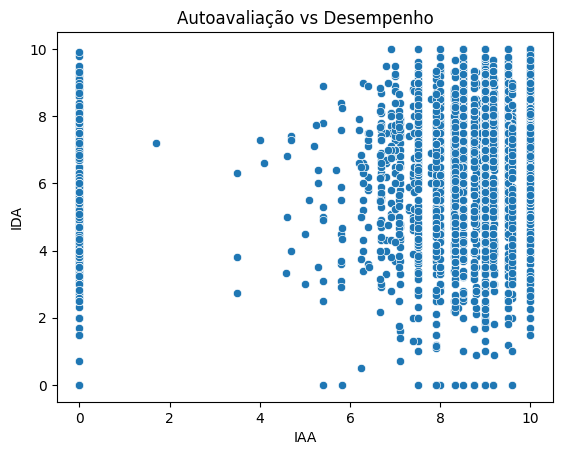

In [78]:
# Gráfico Autoavaliação x Desempenho
sns.scatterplot(data=df_tratado, x='IAA', y='IDA')
plt.title('Autoavaliação vs Desempenho')
plt.show()

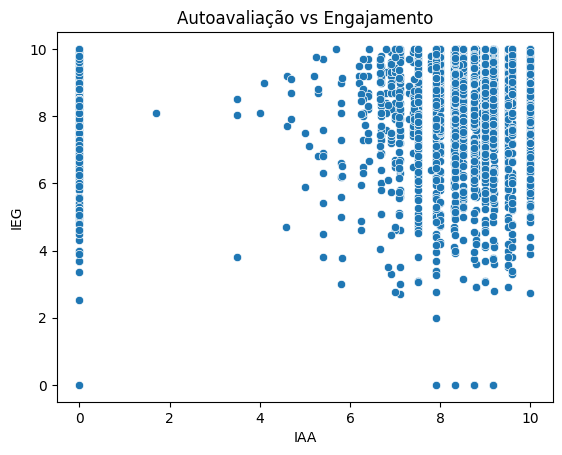

In [79]:
# Correlação entre Autoavaliação x Engajamento
sns.scatterplot(data=df_tratado, x='IAA', y='IEG')
plt.title('Autoavaliação vs Engajamento')
plt.show()

In [81]:
# Analise por Faixa
df_tratado['faixa_IAA'] = pd.qcut(df_tratado['IAA'], 3, labels=['Baixa', 'Média', 'Alta'])

In [83]:
# Comprar com desempenho
df_tratado.groupby('faixa_IAA')['IDA'].mean()

/tmp/ipykernel_23980/282613220.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tratado.groupby('faixa_IAA')['IDA'].mean()


,IDA
faixa_IAA,
Baixa,6.048735
Média,6.440368
Alta,6.642812


Considerando a diferença relativamente pequena entre os grupos, a percepção pode não ser precisa. No entanto, podemos observar uma relação positiva entre a autoavaliação dos alunos e o desempenho academico.

In [84]:
# Comparar com engajamento
df_tratado.groupby('faixa_IAA')['IEG'].mean()

/tmp/ipykernel_23980/3445876857.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tratado.groupby('faixa_IAA')['IEG'].mean()


,IEG
faixa_IAA,
Baixa,7.908269
Média,8.317534
Alta,8.469860


Assim como na relação entre autoavaliação e desempenho, os dados mostram que há uma relação positiva entre a autoavaliação e o engajamento, ou seja, alunos com melhor percepção de si tendem a apresentar melhores resultados. No entanto, as diferenças entre os grupos é relativamente pequena, então essa percepção não é totalmente precisa.